# Sunpy Map Operations
---
This notebook demonstrates how to perform various operations on Sunpy Maps, such as cropping, rotating, and visualizing data. Notably, it includes the general operations that can be applied to any Sunpy Map, as well as the children of the Map class, such as AIAMap, HMIMap, and EISMap. Please use the navigation bar on the left (three horizontal lines) to explore the different sections of this notebook.

In [ ]:
# import packages 
import numpy as np
import matplotlib.pyplot as plt
import sunpy 
import sunpy.map
import astropy.units as u 
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import WCS

## Create Sunpy Map
---
To create a Sunpy Map, you can use the `sunpy.map.Map()` function, which takes the file path of a FITS image as an argument, or a list of file paths if you want to create a Map sequence, or a data array along with a header dictionary, or a data array along with a WCS object. In this example, we will create a Sunpy Map from a FITS file of an AIA 171 image.

First, let us print the file path of the AIA 171 image

In [9]:
from sunpy.data.sample import AIA_171_IMAGE, AIA_193_IMAGE # <-- these are sample AIA images provided by Sunpy
print(AIA_171_IMAGE) # <-- this will print the file path of the AIA 171 image, which is a FITS file. You can use this file path to create a Sunpy Map object.

/home/yjzhu/.local/share/sunpy/AIA20110607_063302_0171_lowres.fits


### Load map from FITS file
---
You can directly create a Sunpy Map object from the AIA 171 FITS file

In [ ]:
smap_171 = sunpy.map.Map(AIA_171_IMAGE) # <-- this creates a Sunpy Map object from the AIA 171 FITS file  

### Load multiple maps together
---
We can load the two maps together and it will returns a list of two Map objects if `sequence` is set to `False` (default), or a MapSequence object if `sequence` is set to `True`. A MapSequence is a list of Map objects that can be treated as a single entity with handy methods for plotting and animation.

In [11]:
smap_list = sunpy.map.Map([AIA_171_IMAGE, AIA_193_IMAGE], sequence=False) # <-- this creates a list of two Map objects from the two AIA FITS files
smap_sequence = sunpy.map.Map([AIA_171_IMAGE, AIA_193_IMAGE], sequence=True) # <-- this creates a MapSequence object from the two AIA FITS files

print("Type of smap_list:", type(smap_list)) # <-- this will print the type of smap_list, which is a list of Map objects
print("Type of smap_sequence:", type(smap_sequence)) # <-- this will print the type of smap_sequence, which is a MapSequence object

Type of smap_list: <class 'list'>
Type of smap_sequence: <class 'sunpy.map.mapsequence.MapSequence'>


### Load map from data array and header
---
We can first load the data array and header from the AIA 171 FITS file using `astropy.io.fits` and then create a Sunpy Map object from the data array and header. This method is useful when you want to manipulate the data array or header before creating the Map object, or some non-standard FITS files that cannot be directly loaded by `sunpy.map.Map()`.

In [16]:
with fits.open(AIA_171_IMAGE) as hdul:
    hdul.info() # <-- this will print the information of the FITS file, including the number of HDUs (Header Data Units) and their types
    data = hdul[1].data.copy() # the primary extension is empty for AIA FITS files
    header = hdul[1].header.copy() # the header information is stored in the first extension for AIA FITS files

Filename: /home/yjzhu/.local/share/sunpy/AIA20110607_063302_0171_lowres.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    201   (1024, 1024)   float32   


In [17]:
smap_171_from_data_and_header = sunpy.map.Map(data, header) # <-- this creates a Sunpy Map object from the data array and header

### Load map from data array and WCS
---
We can also create a Sunpy Map object from a data array and a WCS object. This method is useful when you have the data array and WCS information separately, or you want to create a Map from a non-FITS data source.

In [18]:
with fits.open(AIA_171_IMAGE) as hdul:
    hdul.info() # <-- this will print the information of the FITS file, including the number of HDUs (Header Data Units) and their types
    data = hdul[1].data.copy() # the primary extension is empty for AIA FITS files
    header = hdul[1].header.copy() # the header information is stored in the first extension for AIA FITS files

smap_171_wcs = WCS(header) # <-- this creates a WCS object from the header information
smap_171_from_data_and_wcs = sunpy.map.Map(data, smap_171_wcs) # <-- this creates a Sunpy Map object from the data array and WCS object

Filename: /home/yjzhu/.local/share/sunpy/AIA20110607_063302_0171_lowres.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    201   (1024, 1024)   float32   


## Map Visualization 
---
In this section, we will visualize the Sunpy Map and make adjustments to the plot, such as changing the colormap and adding a colorbar.

### Directly plot the Sunpy Map
---
The simplest way to visualize a Sunpy Map is to directly call the `plot()` method of the Map object. This will create a plot with the default settings, including the default colormap and axis labels.

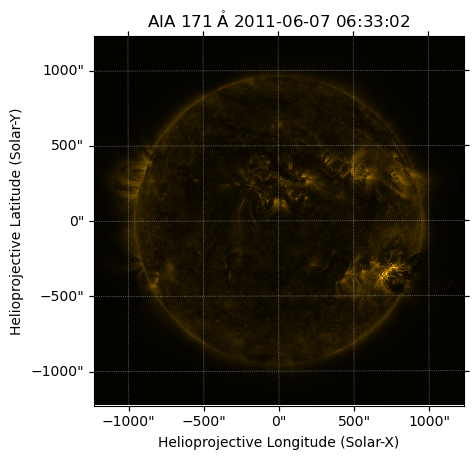

In [6]:
smap_171.plot()